In [101]:
import numpy as np
import matplotlib.pyplot as plt

### Part 1

In [102]:
seed = 30
rng = np.random.default_rng(seed=seed)
N = 10000
p = 0.50
U = rng.uniform(low=0, high=1, size=N)
X = np.floor(np.log(U)/np.log(1-p))+1
X

array([3., 2., 4., ..., 1., 1., 1.])

(array([7.597e+03, 1.193e+03, 6.210e+02, 2.970e+02, 1.450e+02, 8.500e+01,
        3.600e+01, 1.700e+01, 4.000e+00, 5.000e+00]),
 array([ 1. ,  2.1,  3.2,  4.3,  5.4,  6.5,  7.6,  8.7,  9.8, 10.9, 12. ]),
 <BarContainer object of 10 artists>)

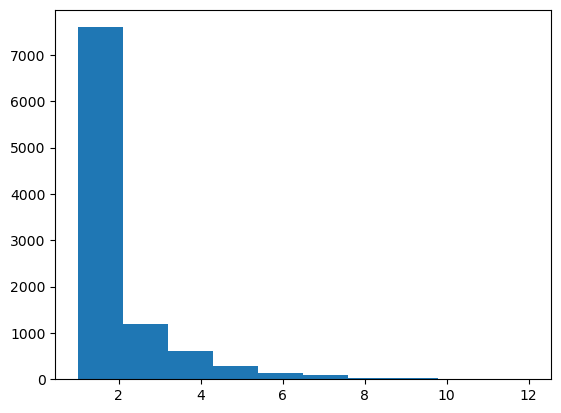

In [103]:
plt.hist(X)

### Part 2

In [115]:
bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5]

Xi = np.array([1,2,3,4,5,6])
P = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
P_partial_sums = np.zeros(len(P))
P_partial_sums[0] = P[0]
for i in range(1,len(P)):
    P_partial_sums[i] = P_partial_sums[i-1] + P[i]

In [105]:
N = 10000
U = rng.uniform(low=0, high=1, size=N)

### Crude method

In [106]:
X_crude = np.zeros(N)
for i in range(N):
    for j in range(len(Xi)):
        if (U[i] < P_partial_sums[j]):
            X_crude[i] = Xi[j]
            break

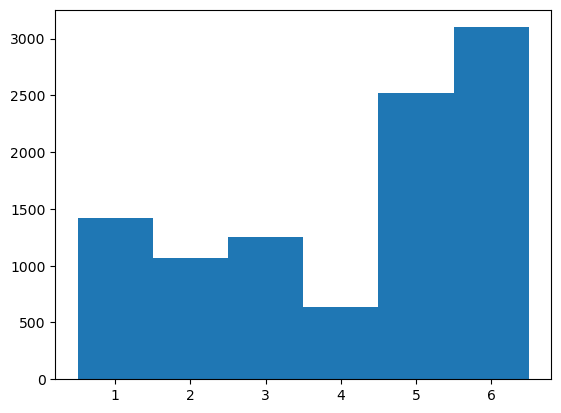

In [107]:
plt.hist(X_crude, bins=bins)
plt.show()

### Rejection method

In [108]:
N = 10000
X_rejection = np.zeros(N)
c = np.max(P)+1
I = np.floor(6*U)+1

for i in range(N):
    while(True):
        I = np.floor(6*rng.uniform(low=0, high=1, size=1)[0])+1
        pI = P[int(I-1)]
        if (rng.uniform(low=0, high=1, size=1)[0] <= pI/c):
            X_rejection[i] = I
            break

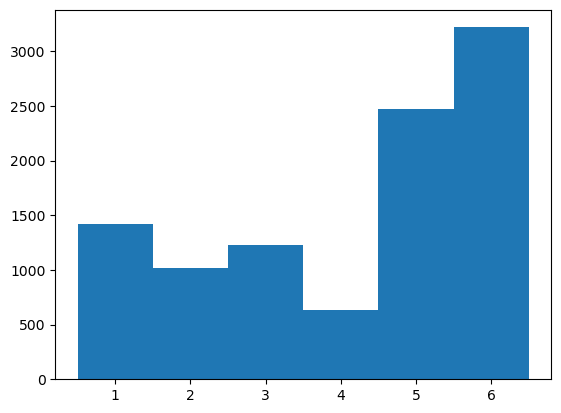

In [109]:
plt.hist(X_rejection, bins=bins)
plt.show()

### Alias method

In [110]:
N/6

1666.6666666666667

In [ ]:
L = Xi
F = 6*P

eps = 1e-6

G = [i for i in Xi if F[i-1] >= 1]
S = [i for i in Xi if F[i-1] <= 1]

while (len(S) > 0):
    i = G[0]
    j = S[0]

    L[j-1] = i
    F[i-1] = F[i-1] - (1 - F[j-1])
    if (F[i-1] < 1 - eps):
        S.append(i)
        G.pop(0)
    S.pop(0)

In [112]:
F, L

(array([0.875, 0.625, 0.75 , 0.375, 0.75 , 1.   ]), array([5, 5, 5, 6, 6, 6]))

In [113]:
N = 10000
#U = rng.uniform(low=0, high=1, size=N)
#I = np.floor(6*U)+1
X_alias = np.zeros(N)

for i in range(N):
    I = int(np.floor(6*rng.uniform(low=0, high=1, size=1)[0])+1)
    if (rng.uniform(low=0, high=1, size=1)[0] <= F[I-1]):
        X_alias[i] = I
    else:
        X_alias[i] = L[I-1]

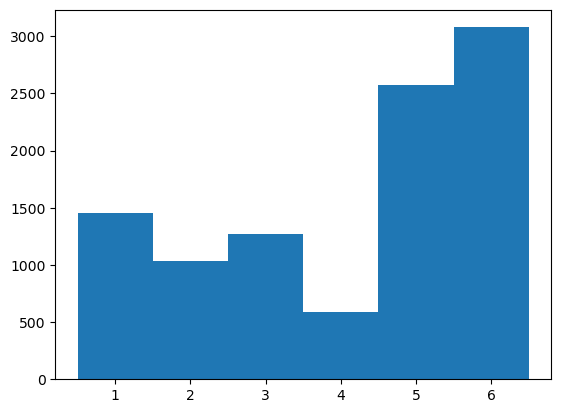

In [114]:
plt.hist(X_alias, bins=bins)
plt.show()